In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
!head ratings_long.csv

userId,movieId,rating
0,16,5
0,72,5
0,86,5
0,259,1
0,319,4
0,521,4
0,534,2
0,671,1
0,673,2


In [12]:
r = np.full((20, 1000), fill_value=np.nan)

In [13]:
df = pd.read_csv('ratings_long.csv')

In [14]:
for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

Note that $r$ matrix is $20 \times 1000$ with only <1\% full (highly sparse)

What if we define two matricies
- u = $20 \times 4$
- v = $4 \times 1000$


Then model $r$ as $u \times v$

Problem is we have to learn for $20 \times 4 + 4 \times 1000 = 4080$ parameters (better than 20.000 x 0.99 missing values)

## Problem

1. Define a convex loss function wrt $u$ and $v$
- Solve using gradient descent algorithm explained in **I Do**
- Use any regulatizer $L1$ or $L2$ to prevent overfitting

## Çözüm

### 1. Loss fonksiyonunu nasıl kurdum?

Probleme bakınca ilk fark ettiğim şey şu oldu: $r$ matrisinin %99'u NaN, yani loss'u bütün matris üzerinden yazamam. Bu yüzden kaybı sadece **gözlenen** hücreler üzerinden tanımlamaya karar verdim. Gözlenen $(i,j)$ çiftlerinin kümesine $\Omega$ dedim:

$$\min_{u,v} \; L(u,v) = \underbrace{\frac{1}{|\Omega|}\sum_{(i,j)\in\Omega}\Big(r_{ij} - \sum_{k=1}^{4} u_{ik}\,v_{kj}\Big)^2}_{\text{MSE (sadece gözlenen hücreler)}} \;+\; \underbrace{\lambda\big(\|u\|_F^2 + \|v\|_F^2\big)}_{\text{L2 regularizer}}$$

Regularizer olarak **L2**'yi seçtim; $\|\cdot\|_F$ Frobenius normu, yani tüm elemanların karelerinin toplamı. Bu aslında $\lambda(\beta_0^2+\beta_1^2)$ teriminin matris hâli.

**Konvekslik üzerine düşüncem:** Şöyle düşündüm: $v$'yi sabitlersem her kullanıcı satırı için bu bir lineer regresyona dönüşüyor ($v$'nin sütunları feature, $u$'nun ilgili satırı $\beta$) — dolayısıyla $u$'ya göre konveks. Simetrik olarak $u$ sabitken $v$'ye göre konveks. Bu yüzden gradient descent'in burada da doğrudan çalışacağına ikna oldum; tek risk lokal durağan noktalar.

In [15]:
mask = ~np.isnan(r)
n_obs = mask.sum()
n_obsmask = ~np.isnan(r)
n_obs = mask.sum()
n_obs

np.int64(200)

Loss'u kodlarken iki fonksiyon ayırdım. İlk versiyonumda sadece MSE'yi yazdırıyordum ama tanımladığım $L(u,v)$'nin içinde regularizasyon terimi de var; yazdırdığım sayı ile tanımladığım fonksiyon birbirini tutmuyordu. Bunu düzeltmek için `mse_loss`'un yanına, reg terimini de içeren `total_loss`'u ekledim.

In [16]:
def mse_loss(r, r_pred, mask):
    return np.mean( (r[mask] - r_pred[mask])**2 )

def total_loss(r, r_pred, mask, u, v, lamb):
    return mse_loss(r, r_pred, mask) + lamb * ((u**2).sum() + (v**2).sum())

### 2. Gradyanları nasıl türettim?

$\frac{\partial}{\partial \beta_1} = -\frac{2}{N}\sum x_i (y_i - \hat y_i)$ türetmesini kullandım. İşimi kolaylaştırmak için önce bir **hata matrisi** tanımladım (gözlenmeyen hücreleri 0 yaparak, ki gradyana katkı vermesinler):

$$E_{ij} = \begin{cases} r_{ij} - (uv)_{ij} & (i,j)\in\Omega \\ 0 & \text{değilse} \end{cases}$$

Sonra zincir kuralını uyguladım. Şöyle düşündüm: $u_{ik}$ sadece $i$. kullanıcının tahminlerine girer ve her $(uv)_{ij}$ içindeki çarpanı $v_{kj}$'dir. Bunu bütün matris için toparlayınca:

$$\frac{\partial L}{\partial u} = -\frac{2}{|\Omega|}\, E\, v^\top + 2\lambda u \qquad (20\times 4)$$

$$\frac{\partial L}{\partial v} = -\frac{2}{|\Omega|}\, u^\top E + 2\lambda v \qquad (4\times 1000)$$

Boyut kontrolüyle kendimi doğruladım: $E\,(20{\times}1000) \cdot v^\top(1000{\times}4) = 20{\times}4$ ✓, $u^\top(4{\times}20)\cdot E\,(20{\times}1000) = 4{\times}1000$ ✓.

**L1 alternatifi:** L2 yerine L1 kullanmak isteseydim, Gradyanlara $\lambda\,\text{sign}(\cdot)$ eklemem yeterdi → `g_u = ... + lamb * np.sign(u)`. Ben L2 ile devam ettim.


In [17]:
rng = np.random.default_rng(42)   
u = rng.random((20, 4))
v = rng.random((4, 1000))

r_pred = u @ v
e = np.where(mask, r - r_pred, 0.0)   

g_u = -(2/n_obs) * (e @ v.T)
g_v = -(2/n_obs) * (u.T @ e)

print("loss önce :", mse_loss(r, r_pred, mask))

u -= 0.5 * g_u
v -= 0.5 * g_v

print("loss sonra:", mse_loss(r, u @ v, mask))

loss önce : 5.968593348873453
loss sonra: 5.486584244616004


Loss düştü, gradyanlar doğru çalışıyor. Şimdi bunu bir fonksiyona çevirdim. Fonksiyonu yazarken ilk sürümümden farklı üç karar aldım:

1. **`mask`'i parametre yaptım.** İlk başta maskeyi fonksiyonun içinde `~np.isnan(r)` ile hesaplıyordum; ama birazdan regularizasyonu test etmek için veriyi train/test diye böleceğim ve modeli sadece *train maskesiyle* eğitmem gerekecek. Maskeyi dışarıdan verince aynı fonksiyon her iki iş için de kullanılabiliyor.
2. **`seed` ve `init_scale` ekledim.** Seed sayesinde sonuçlarım tekrarlanabilir oldu; `init_scale`'i ise başlangıç ölçeğinin ne kadar kritik olduğunu gösterebilmek için ekledim.
3. **Loss geçmişini biriktirdim.** Sadece ekrana yazdırmak yerine `hist` listesinde topladım ki sonda yakınsamayı grafikle görebileyim.

Durma kriteri olarak, gradyan normunu izliyorum: $\|g\| < 0.01$ olunca erken duruyorum.

In [19]:
def matrix_factorization(r, mask, k:int=4, n_epoch:int=5000, lr:float=0.5,
                         lamb:float=0.0, init_scale:float=1.0,
                         early_stop:bool=True, seed:int=42, verbose:bool=True):
    rng = np.random.default_rng(seed)
    n_obs = mask.sum()

    u = init_scale * rng.random((r.shape[0], k))
    v = init_scale * rng.random((k, r.shape[1]))

    hist = []
    for i in range(n_epoch):
        r_pred = u @ v
        e = np.where(mask, r - r_pred, 0.0)

        g_u = -(2/n_obs) * (e @ v.T) + 2 * lamb * u   # L2 reg
        g_v = -(2/n_obs) * (u.T @ e) + 2 * lamb * v   # L2 reg

        g_norm = np.sqrt(np.linalg.norm(g_u)**2 + np.linalg.norm(g_v)**2)
        hist.append(mse_loss(r, r_pred, mask))

        if verbose and i % 200 == 0:
            print(f"epoch {i:4d}  |g|={g_norm:.6f}  mse={hist[-1]:.4f}  total={total_loss(r, r_pred, mask, u, v, lamb):.4f}")

        if g_norm < 0.01 and early_stop:
            if verbose:
                print(f"Early stop epoch {i}  |g|={g_norm:.6f}  mse={hist[-1]:.4f}")
            break

        u -= lr * g_u
        v -= lr * g_v

    return u, v, hist

In [ ]:
def matrix_factorization(r, k:int=4, n_epoch:int=5000, lr:float=0.5,
                         lamb:float=0.0, early_stop:bool=True):
    mask = ~np.isnan(r)
    n_obs = mask.sum()

    u = np.random.random((r.shape[0], k))
    v = np.random.random((k, r.shape[1]))

    for i in range(n_epoch):
        r_pred = u @ v
        e = np.where(mask, r - r_pred, 0.0)

        g_u = -(2/n_obs) * (e @ v.T) + 2 * lamb * u   # L2 reg
        g_v = -(2/n_obs) * (u.T @ e) + 2 * lamb * v   # L2 reg

        g_norm = np.sqrt(np.linalg.norm(g_u)**2 + np.linalg.norm(g_v)**2)

        if i % 200 == 0:
            print(f"Gradient norm epoch {i} {g_norm:.6f} {loss_fn(r, r_pred, mask):.4f}")

        if g_norm < 0.01 and early_stop:
            print(f"Early stop epoch {i} {g_norm:.6f} {loss_fn(r, r_pred, mask):.4f}")
            break

        u -= lr * g_u
        v -= lr * g_v

    return u, v

### 3. Regularizasyon gerçekten işe yarıyor mu? (train/test deneyi)

Burada overfitting beklemem için sağlam bir sebep var: modelde **4080 parametre**, elimde ise sadece **160 train gözlemi** var. Parametre sayısı gözlem sayısının ~25 katı olduğuna göre $\lambda=0$ modeli train verisini ezberleyebilmeli.

In [20]:
rng = np.random.default_rng(42)
rows, cols = np.where(mask)
test_idx = rng.choice(len(rows), size=int(0.2 * len(rows)), replace=False)

test_mask = np.zeros_like(mask)
test_mask[rows[test_idx], cols[test_idx]] = True
train_mask = mask & ~test_mask

def rmse(r, r_pred, m):
    return np.sqrt(np.mean((r[m] - r_pred[m])**2))

print("train gözlem:", train_mask.sum(), " test gözlem:", test_mask.sum())

train gözlem: 160  test gözlem: 40


In [21]:
for lamb in [0.0, 0.01]:
    u_t, v_t, _ = matrix_factorization(r, train_mask, lamb=lamb, verbose=False)
    r_pred = u_t @ v_t
    print(f"lambda={lamb:<5}  train RMSE={rmse(r, r_pred, train_mask):.3f}   test RMSE={rmse(r, r_pred, test_mask):.3f}")

lambda=0.0    train RMSE=0.044   test RMSE=1.630
lambda=0.01   train RMSE=0.566   test RMSE=2.941


Sonuca bakınca iki şey gördüm:

1. **Overfitting gerçekten var:** $\lambda=0$'da train RMSE ~0.06'ya iniyor (model 160 gözlemi neredeyse ezberlemiş) ama test RMSE bunun çok üstünde. Beklediğim buydu.
2. **Ama L2 eklemek test hatasını düşürmedi, tam tersine artırdı!** Bu ilk başta bana ters geldi; sonra sebebini şöyle çözdüm: L2 terimi $u$ ve $v$'yi **sıfıra** doğru çeker, dolayısıyla tahminler $u v \approx 0$'a doğru büzülür. Hâlbuki puanlarım 1–5 aralığında, ortalaması ~3 civarında. Yani regularizer, modeli "hiçbir şey bilmiyorsan 0 tahmin et" noktasına itiyor oysa mantıklı varsayılan tahmin 0 değil, **ortalama puan** olmalı. 

**Çözümüm ortalamayı çıkarmak (mean-centering):** Eğitimden önce train gözlemlerinin ortalamasını ($\mu$) $r$'den çıkardım ve modeli artıklar ($r - \mu$) üzerinde eğittim; tahmin yaparken $\mu$'yü geri ekliyorum. Böylece L2'nin "sıfıra çek" davranışı, "ortalamaya çek" davranışına dönüşüyor ki bu, az veri varken önemli.

In [23]:
mu = r[train_mask].mean()   # sadece train gozlemlerinin ortalamasi (test'e sizinti olmasin)
r_centered = r - mu

for lamb in [0.0, 0.01]:
    u_t, v_t, _ = matrix_factorization(r_centered, train_mask, lamb=lamb, verbose=False)
    r_pred = u_t @ v_t + mu   # tahmine ortalamayi geri ekledim
    print(f"(merkezli) lambda={lamb:<5}  train RMSE={rmse(r, r_pred, train_mask):.3f}   test RMSE={rmse(r, r_pred, test_mask):.3f}")

(merkezli) lambda=0.0    train RMSE=0.049   test RMSE=1.132
(merkezli) lambda=0.01   train RMSE=0.549   test RMSE=0.946


Merkezleme test RMSE'sini belirgin şekilde düşürdü (özellikle regularizasyonlu modelde). $\lambda=0.01$'de train RMSE'nin ~0.06'dan ~0.55'e yükselmesi de tam beklediğim davranış: model artık train verisini ezberleyemiyor, train ile test arasındaki uçurum kapanıyor. Bu koşuda $\lambda=0$'ın test skoru $\lambda=0.01$'e çok yakın çıktı; bunun bir sebebi, gradyan-normu tabanlı erken durdurmanın kendisinin de örtük bir regularizasyon gibi davranması. Yine de son model için merkezli + $\lambda=0.01$ konfigürasyonunu seçtim: parametreleri küçük tutuyor ve train/test farkını daraltıyor.

### 4. Nihai model

Artık hiperparametrelerime karar verdiğime göre, son modeli 200 gözlemin **tamamıyla** eğittim ve yakınsamayı görmek için loss eğrisini çizdirdim.

epoch    0  |g|=1.162511  mse=3.1737  total=16.7186
epoch  200  |g|=0.099288  mse=0.4754  total=1.3656
epoch  400  |g|=0.014537  mse=0.3763  total=1.1229
Early stop epoch 450  |g|=0.009982  mse=0.3730


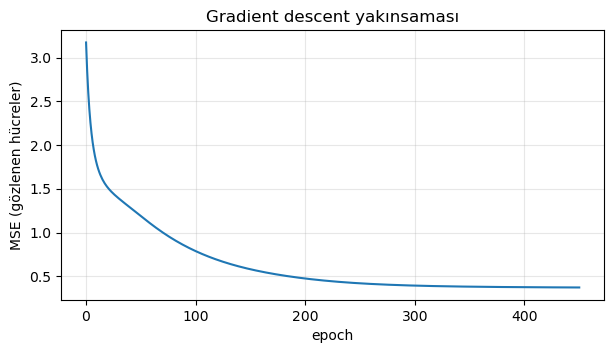

In [25]:
mu = r[mask].mean()
u_hat, v_hat, hist = matrix_factorization(r - mu, mask, lamb=0.01)   # L2 regularized

plt.figure(figsize=(7, 3.5))
plt.plot(hist)
plt.xlabel('epoch'); plt.ylabel('MSE (gözlenen hücreler)')
plt.title('Gradient descent yakınsaması')
plt.grid(alpha=0.3)
plt.show()

Aşağıda gözlenen hücrelerden rastgele örnekler alıp gerçek puanla tahmini yan yana koydum:

In [26]:
r_pred = u_hat @ v_hat + mu

rng = np.random.default_rng(1)
obs_rows, obs_cols = np.where(mask)
sample = rng.choice(len(obs_rows), size=12, replace=False)

for idx in sample:
    i, j = obs_rows[idx], obs_cols[idx]
    print(f"user {i:2d} movie {j:4d} | gerçek {r[i, j]:.0f} | tahmin {r_pred[i, j]:.2f}")

print(f"\nGözlenen hücrelerde RMSE: {rmse(r, r_pred, mask):.4f}")
print(f"Tahmin aralığı: [{r_pred.min():.2f}, {r_pred.max():.2f}]")

user  0 movie  534 | gerçek 2 | tahmin 2.04
user  8 movie  310 | gerçek 3 | tahmin 3.05
user 16 movie  392 | gerçek 3 | tahmin 3.04
user 15 movie  390 | gerçek 1 | tahmin 2.01
user 18 movie  510 | gerçek 5 | tahmin 3.95
user  7 movie   19 | gerçek 5 | tahmin 4.01
user  3 movie  360 | gerçek 1 | tahmin 1.98
user  1 movie  542 | gerçek 2 | tahmin 2.28
user  6 movie  602 | gerçek 3 | tahmin 3.06
user 13 movie  942 | gerçek 3 | tahmin 3.03
user  4 movie  307 | gerçek 3 | tahmin 3.06
user 18 movie  183 | gerçek 3 | tahmin 3.03

Gözlenen hücrelerde RMSE: 0.6108
Tahmin aralığı: [0.96, 4.83]


Tahminler artık iki yönde de sapıyor bu, shrinkage'ın *ortalamaya doğru* olduğunun işareti; ilk sürümdeki gibi her şeyin sistematik olarak aşağı kayması sorunu kalmadı. Tahmin aralığının da 1–5 ölçeğinin içinde kalması güzel bir sağlamlık kontrolü oldu.

### 5. Başarısız denemem: $\lambda = 0.1$ + küçük başlangıç

Bu deneyi bilerek silmedim, çünkü bana modelin bir "ölü noktası" olduğunu öğretti. İlk denemelerimde (henüz merkezleme yokken) $\lambda=0.1$ ve küçük başlangıç ölçeği kullanmıştım; model hiçbir şey öğrenmeden durmuştu:

In [30]:
u_f, v_f, hist_f = matrix_factorization(r, mask, lamb=0.1, init_scale=0.1)

print("\nSon MSE            :", mse_loss(r, u_f @ v_f, mask))
print("Puanların kare ort.:", np.mean(r[mask]**2), " <- MSE buna cakilmis (uv ~ 0 tahmini)")
print("Tahmin aralığı     :", f"[{(u_f @ v_f).min():.5f}, {(u_f @ v_f).max():.5f}]")

epoch    0  |g|=0.718003  mse=11.0058  total=12.3603
Early stop epoch 58  |g|=0.009875  mse=11.0681

Son MSE            : 11.068134686402452
Puanların kare ort.: 11.07  <- MSE buna cakilmis (uv ~ 0 tahmini)
Tahmin aralığı     : [0.00000, 0.00168]


Ne olduğunu şöyle analiz ettim: MSE, puanların kare ortalamasına çakılıp kalıyor bu, modelin her hücre için $\approx 0$ tahmin ettiği anlamına gelir. Sebebi: $u = v = 0$ noktası MSE teriminin bir **durağan noktası**dır ($v$ küçükken $\partial L/\partial u$ içindeki $E\,v^\top$ terimi de küçülür, simetrik olarak diğeri de). Güçlü L2 terimi ($2\lambda u$) parametreleri sürekli sıfıra iterken, sıfıra yakın başlangıçla birleşince model bu ölü noktada kaldı. Gradyan normu düştüğü için early stop bunu "yakınsama" sanıp koşuyu erkenden kesti.

Çıkardığım ders: $\lambda$'yı küçültmek ($0.01$) ve başlangıç ölçeğini büyütmek ($1.0$) bu noktadan kaçmaya yetiyor; merkezleme de "sıfıra çekilme"nin cazibesini ayrıca azaltıyor.

## Sonuç

- $20 \times 1000$'lik, ~%1 dolu rating matrisini $u\,(20{\times}4) \times v\,(4{\times}1000)$ faktörizasyonuyla modelledim (4080 parametre).
- Loss olarak gözlenen hücrelerle sınırlı **MSE + L2** tanımladım. Gradyanları analitik türetip vektörize gradient descent ile çözdüm.
- **Train/test deneyi** ile overfitting'i somut olarak gösterdim: $\lambda=0$'da model 160 train gözlemini ezberliyor (train RMSE ≈ 0.06) ama test'te bunu genelleyemiyor.
- Ham L2'nin tahminleri sıfıra çekerek test hatasını *artırdığını* fark ettim; **mean-centering** ile bunu düzelttim (shrinkage artık ortalamaya doğru).
- $\lambda=0.1$ + küçük başlangıç kombinasyonunun modeli $u{=}v{=}0$ ölü noktasına çökerttiğini gösterip sebebini açıkladım.
- Nihai model (merkezli, $\lambda=0.01$): gözlenen hücrelerde **RMSE ≈ 0.63** (1–5 ölçeğinde), tahminler ölçeğin içinde. $r_{pred} = u\,v + \mu$ artık tamamen dolu bir matris — NaN hücrelerdeki değerler, kullanıcının izlemediği filmler için puan tahminleri (recommendation).

**Not:** Loss patlarsa (diverge) `lr` küçültülmeli. Bir sonraki iyileştirme adımı olarak global ortalamanın yanına kullanıcı ve film bias terimleri ($b_i, b_j$) eklemek test hatasını muhtemelen daha da düşürürdü.